# Pump it Up: Data Mining the Water Table
## Problem description
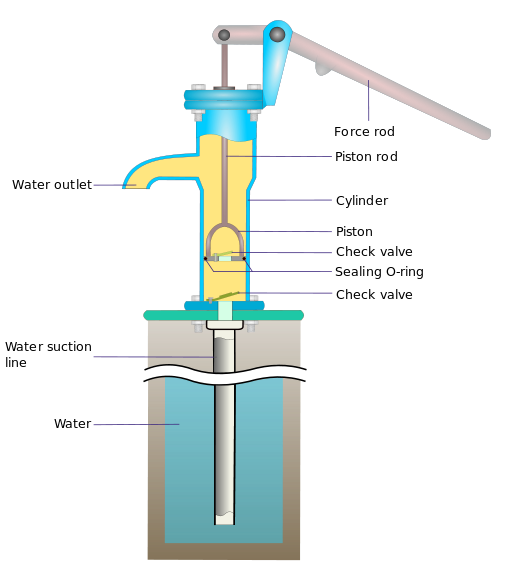

Your goal is to predict the operating condition of a waterpoint for each record in the dataset. You are provided the following set of information about the waterpoints:

- amount_tsh - Total static head (amount water available to waterpoint)
- date_recorded - The date the row was entered
- funder - Who funded the well
- gps_height - Altitude of the well
- installer - Organization that installed the well
- longitude - GPS coordinate
- latitude - GPS coordinate
- wpt_name - Name of the waterpoint if there is one
- num_private -
- basin - Geographic water basin
- subvillage - Geographic location
- region - Geographic location
- region_code - Geographic location (coded)
- district_code - Geographic location (coded)
- lga - Geographic location
- ward - Geographic location
- population - Population around the well
- public_meeting - True/False
- recorded_by - Group entering this row of data
- scheme_management - Who operates the waterpoint
- scheme_name - Who operates the waterpoint
- permit - If the waterpoint is permitted
- construction_year - Year the waterpoint was constructed
- extraction_type - The kind of extraction the waterpoint uses
- extraction_type_group - The kind of extraction the waterpoint uses
- extraction_type_class - The kind of extraction the waterpoint uses
- management - How the waterpoint is managed
- management_group - How the waterpoint is managed
- payment - What the water costs
- payment_type - What the water costs
- water_quality - The quality of the water
- quality_group - The quality of the water
- quantity - The quantity of water
- quantity_group - The quantity of water
- source - The source of the water
- source_type - The source of the water
- source_class - The source of the water
- waterpoint_type - The kind of waterpoint
- waterpoint_type_group - The kind of waterpoint

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,accuracy_score

pylab.rcParams["figure.figsize"] = (14,8)

### 1. Loading Data

In [2]:
features = pd.read_csv("training_set_values.csv")
labels = pd.read_csv("training_set_labels.csv")

In [3]:
# merge features and labels into one dataframe
df = pd.merge(features,labels,how='left',on="id")

In [4]:
df.shape

(59400, 41)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

### 2. Data investigation and visualization

- Check number in each target's class

In [6]:
df["status_group"].value_counts().index

Index(['functional', 'non functional', 'functional needs repair'], dtype='object', name='status_group')

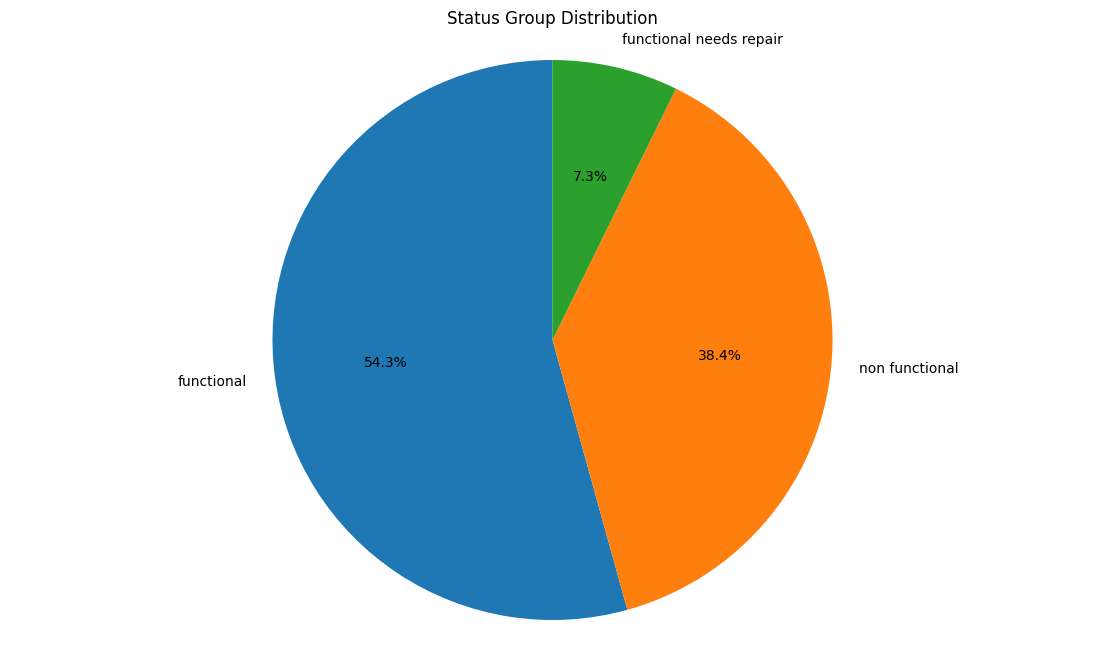

In [7]:
label_dict = {"functional":0,"functional needs repair":1,"non functional":2}
df["label"] = df["status_group"].map(label_dict)
plt.pie(df["status_group"].value_counts().to_list(),
        labels=df["status_group"].value_counts().index, 
        autopct='%1.1f%%', startangle=90)
# Add a title
plt.title('Status Group Distribution')
# Ensure the circle is drawn as a perfect circle
plt.axis('equal')
# Display the chart
plt.show()

- Numerical Features

In [8]:
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year,label
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475,0.841162
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547,0.949794
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000,0.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000,2.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000,2.000000


-  Most of non-functional pumps were built in 1985

Text(0, 0.5, 'No. constructed pumps')

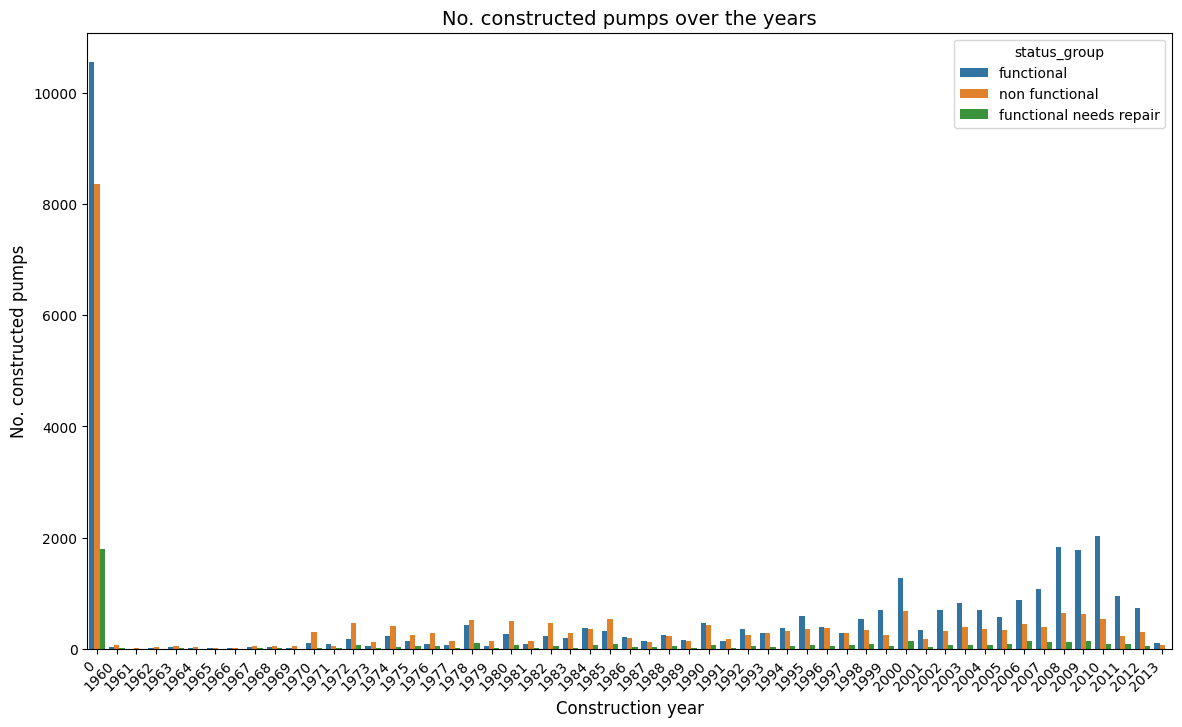

In [9]:
sns.countplot(x=df["construction_year"],hue=df["status_group"])
plt.xticks(rotation=45, 
    horizontalalignment='right')
plt.title("No. constructed pumps over the years", fontsize=14)
plt.xlabel("Construction year", fontsize=12)
plt.ylabel("No. constructed pumps", fontsize=12)

<Axes: xlabel='status_group', ylabel='amount_tsh'>

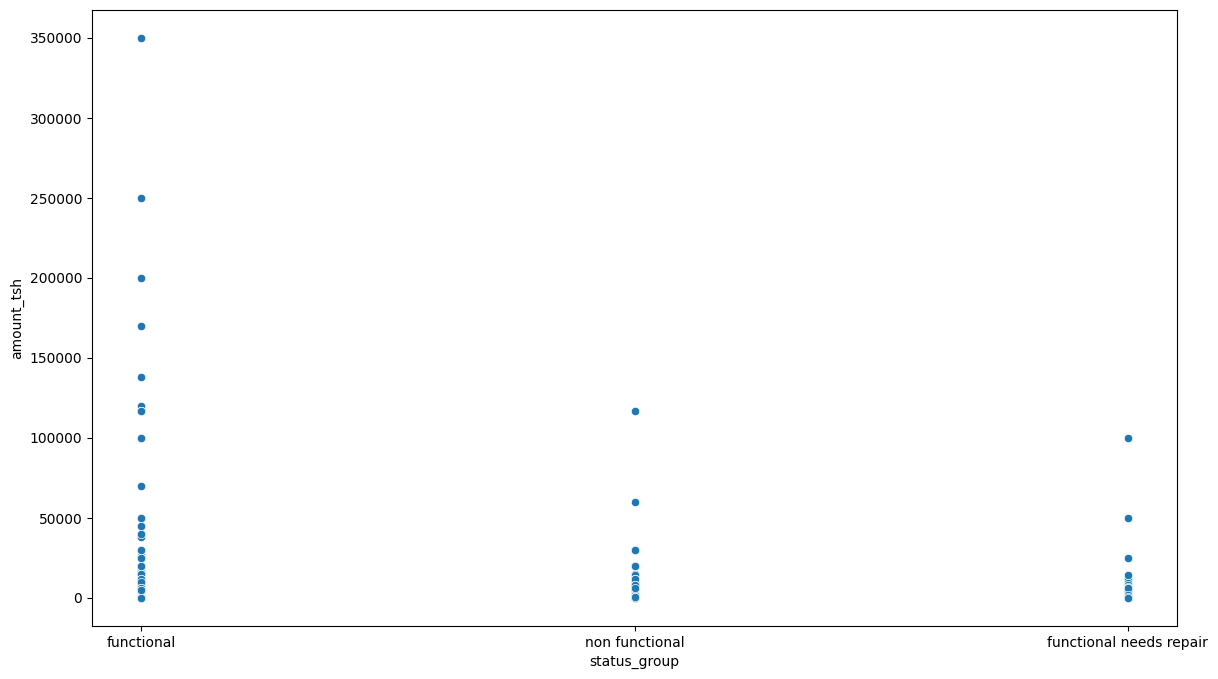

In [10]:
sns.scatterplot(y=df["amount_tsh"],x=df["status_group"])


In [11]:
numerical_features = df.dtypes[(df.dtypes == 'int64') | (df.dtypes == 'float64')].index.to_list()
numerical_features

['id',
 'amount_tsh',
 'gps_height',
 'longitude',
 'latitude',
 'num_private',
 'region_code',
 'district_code',
 'population',
 'construction_year',
 'label']

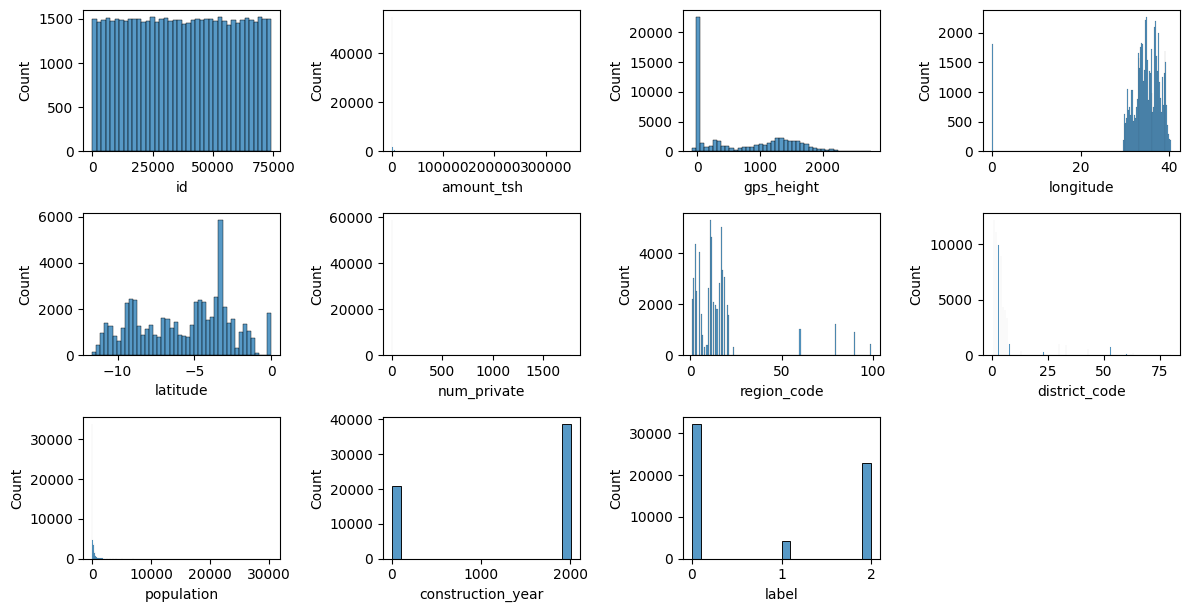

In [12]:
fig = plt.figure(figsize=(12,18))
sns.distributions._has_statsmodels=False
for i in range(len(numerical_features)):
    fig.add_subplot(9,4,i+1)
    sns.histplot(df[numerical_features].iloc[:,i].dropna())
    plt.xlabel(numerical_features[i])

plt.tight_layout()
plt.show()

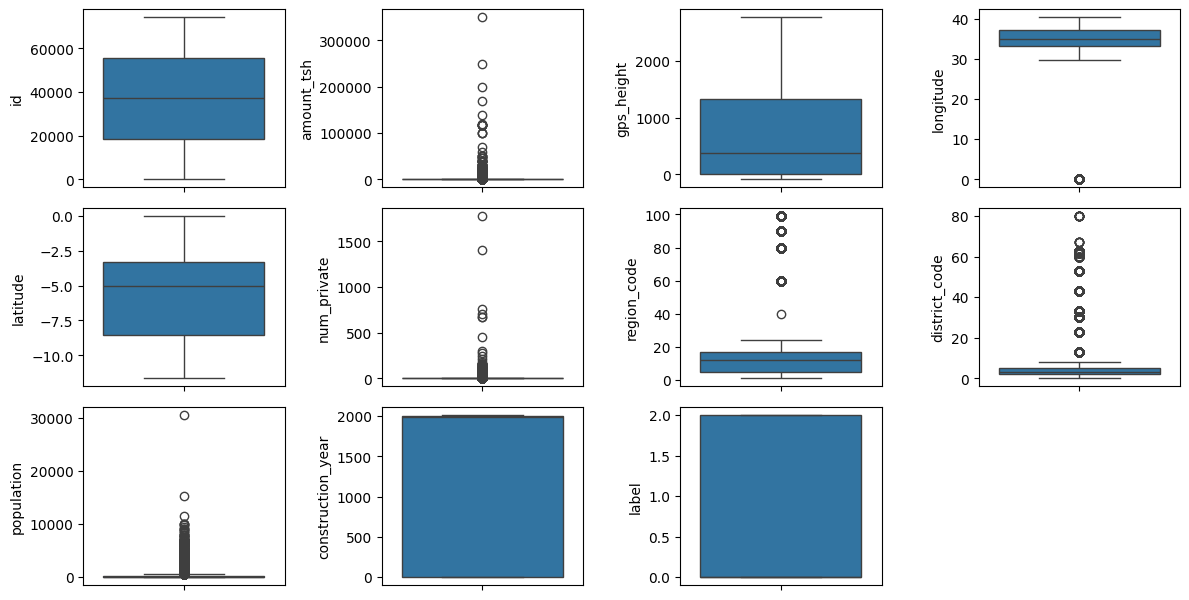

In [13]:
fig = plt.figure(figsize=(12, 18))

for i in range(len(numerical_features)):
    fig.add_subplot(9, 4, i+1)
    sns.boxplot(y=df[numerical_features].iloc[:,i])

plt.tight_layout()
plt.show()

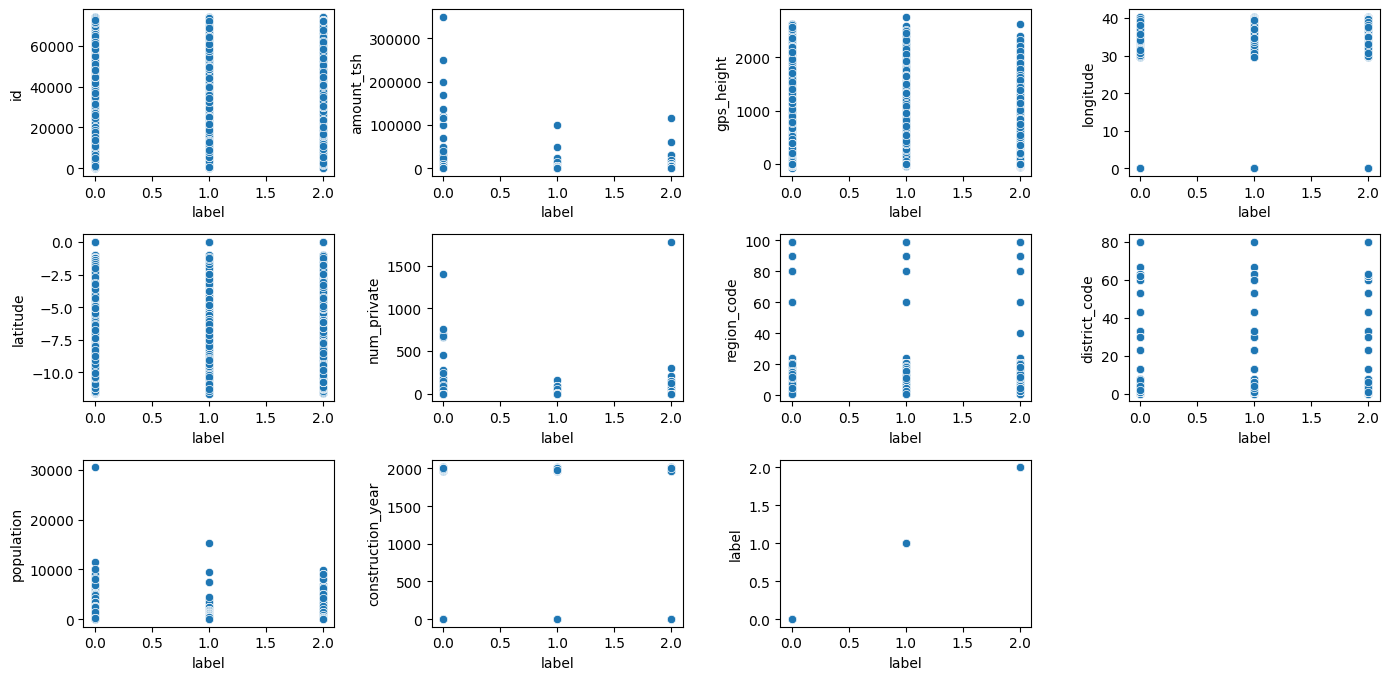

In [14]:
f = plt.figure(figsize=(14,20))

for i in range(len(numerical_features)):
    f.add_subplot(9, 4, i+1)
    sns.scatterplot(y=df[numerical_features].iloc[:,i], x=df["label"])
    
plt.tight_layout()
plt.show()

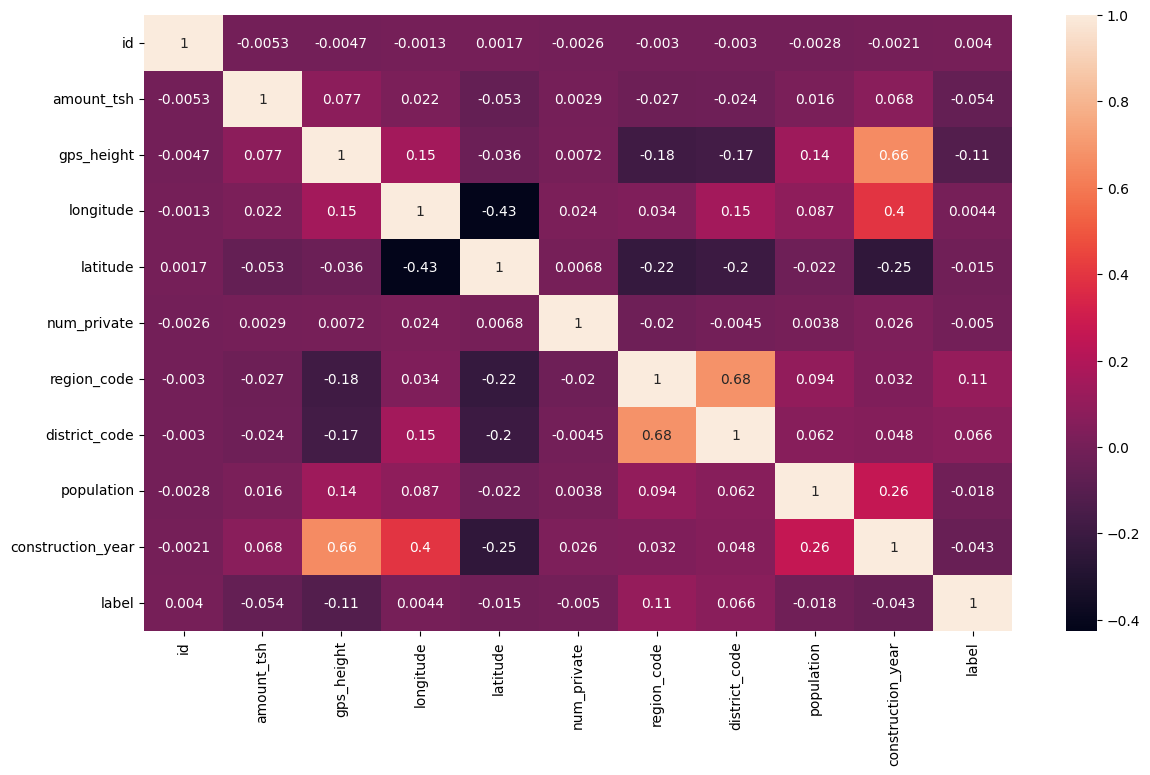

In [15]:
sns.heatmap(df[numerical_features].corr(method="pearson"),
            annot=True)
plt.show()

In [16]:
correlation = df[numerical_features].corr()
correlation['label'].sort_values(ascending=False)

label                1.000000
region_code          0.108640
district_code        0.065687
longitude            0.004366
id                   0.004049
num_private         -0.005021
latitude            -0.014547
population          -0.017759
construction_year   -0.043342
amount_tsh          -0.053702
gps_height          -0.114029
Name: label, dtype: float64

- Categorical columns

In [17]:
str_features = df.select_dtypes(include='object').columns
print(str_features)

Index(['date_recorded', 'funder', 'installer', 'wpt_name', 'basin',
       'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'extraction_type',
       'extraction_type_group', 'extraction_type_class', 'management',
       'management_group', 'payment', 'payment_type', 'water_quality',
       'quality_group', 'quantity', 'quantity_group', 'source', 'source_type',
       'source_class', 'waterpoint_type', 'waterpoint_type_group',
       'status_group'],
      dtype='object')


In [18]:
na_summary = (
    pd.DataFrame({
        'n_missing': df[str_features].isna().sum(),
        'nunique': df[str_features].nunique()
    })
    .query('n_missing > 0')
    .sort_values('n_missing', ascending=False)
)
na_summary


,n_missing,nunique
scheme_name,28810,2695
scheme_management,3878,11
installer,3655,2145
funder,3637,1896
public_meeting,3334,2
permit,3056,2
subvillage,371,19287
wpt_name,2,37399


The following groups of similar features

- (extraction_type, extraction_type_group, extraction_type_class),
- (payment, payment_type),
- (water_quality, quality_group),
- (source, source_class),
- (subvillage, region, region_code, district_code, lga, ward),
- (waterpoint_type, waterpoint_type_group)
- (scheme_name, scheme_management)

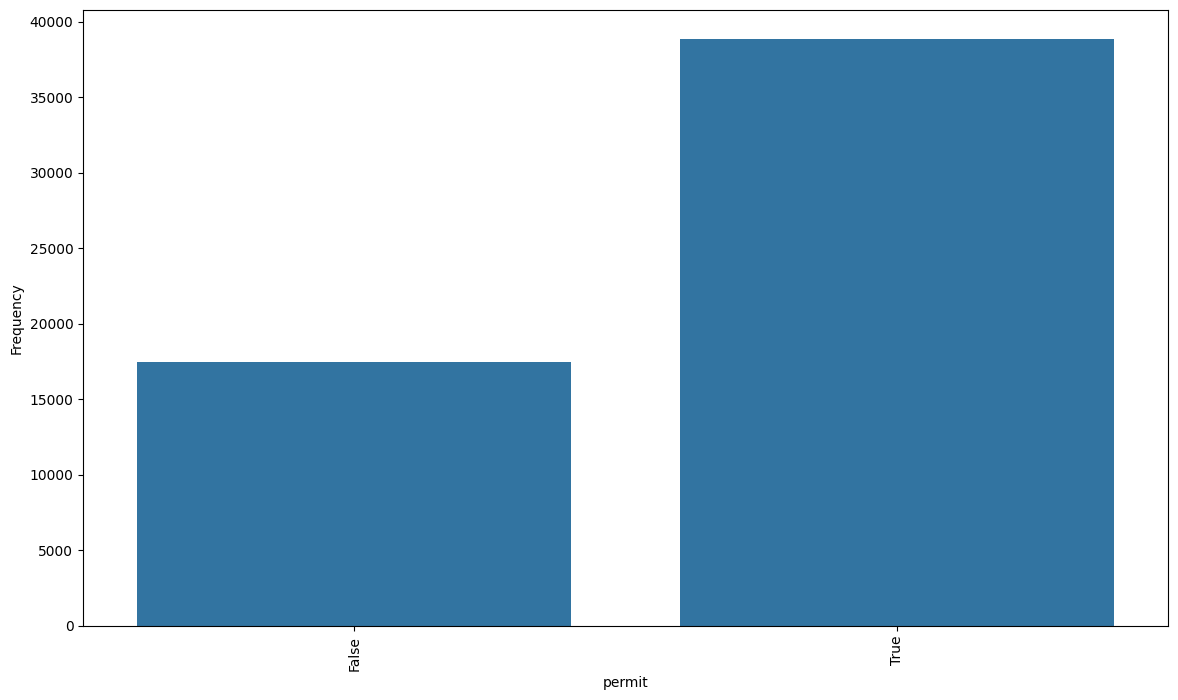

In [19]:
## Count of categories within Scheme_management attribute
sns.countplot(x='permit', data=df)
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.show()

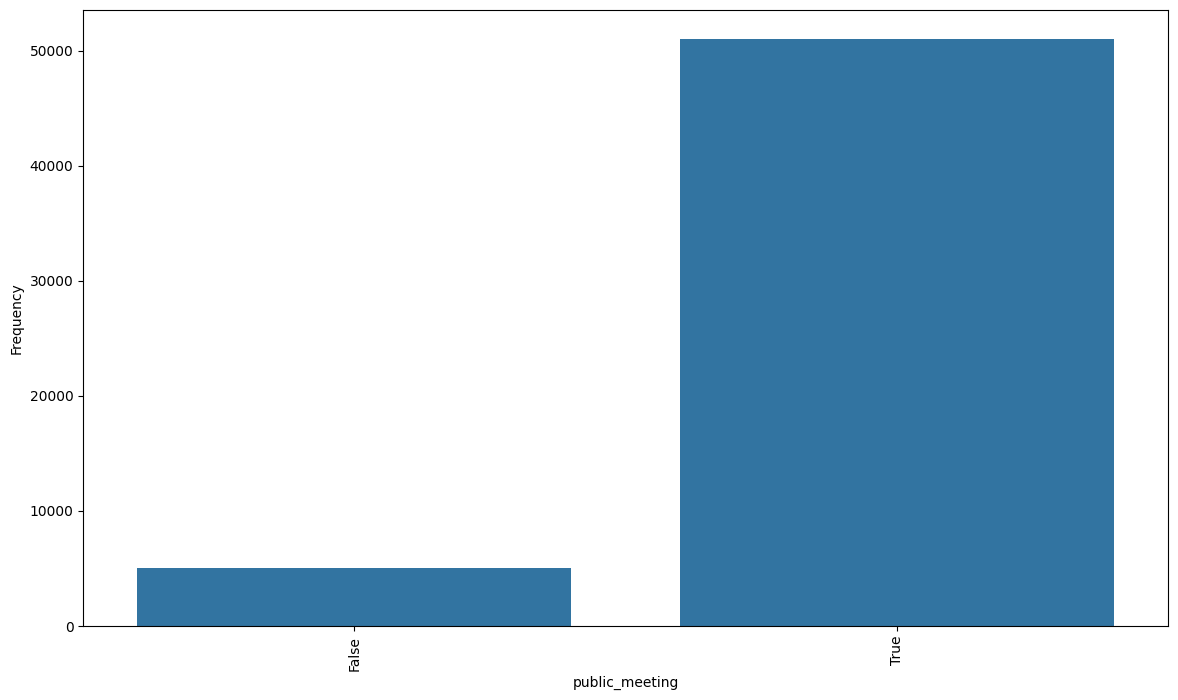

In [20]:
## Count of categories within Scheme_management attribute
sns.countplot(x='public_meeting', data=df)
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.show()

In [21]:
df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group', 'label'],
      dtype='object')

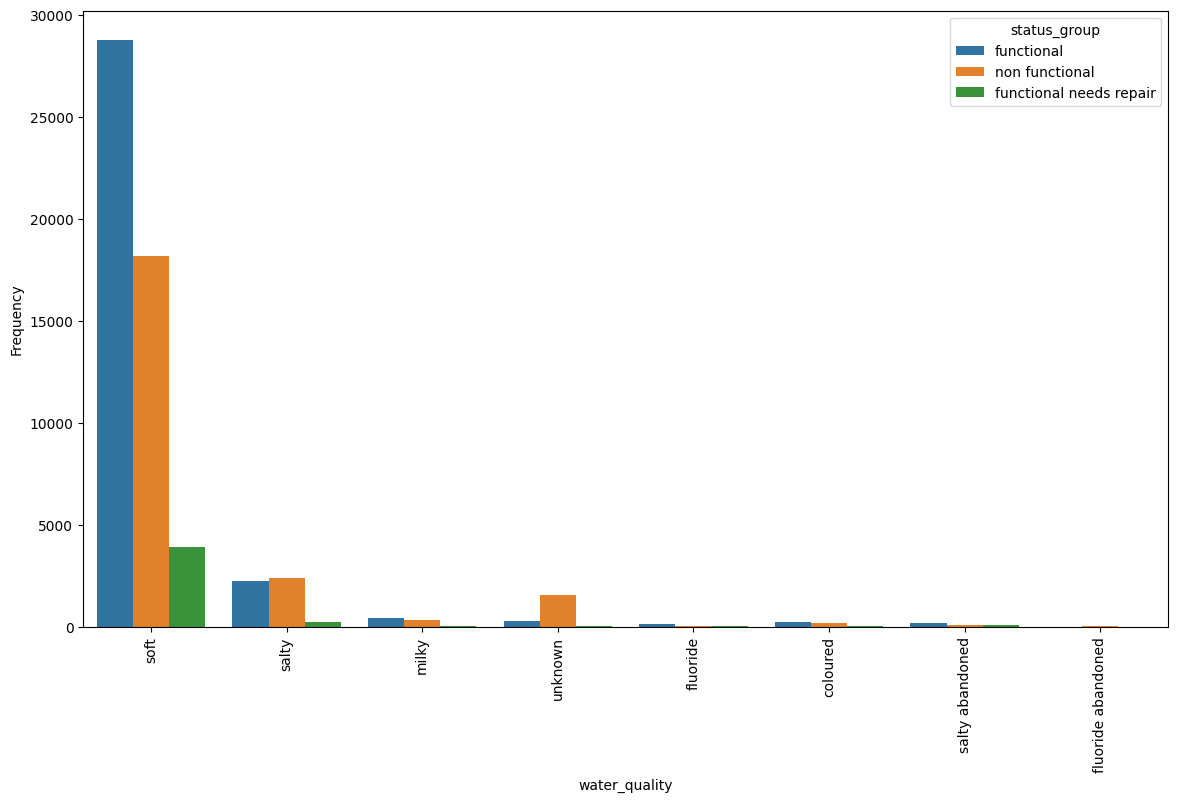

In [22]:
## Count of categories within Scheme_management attribute
sns.countplot(x='water_quality', data=df, hue='status_group')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.show()

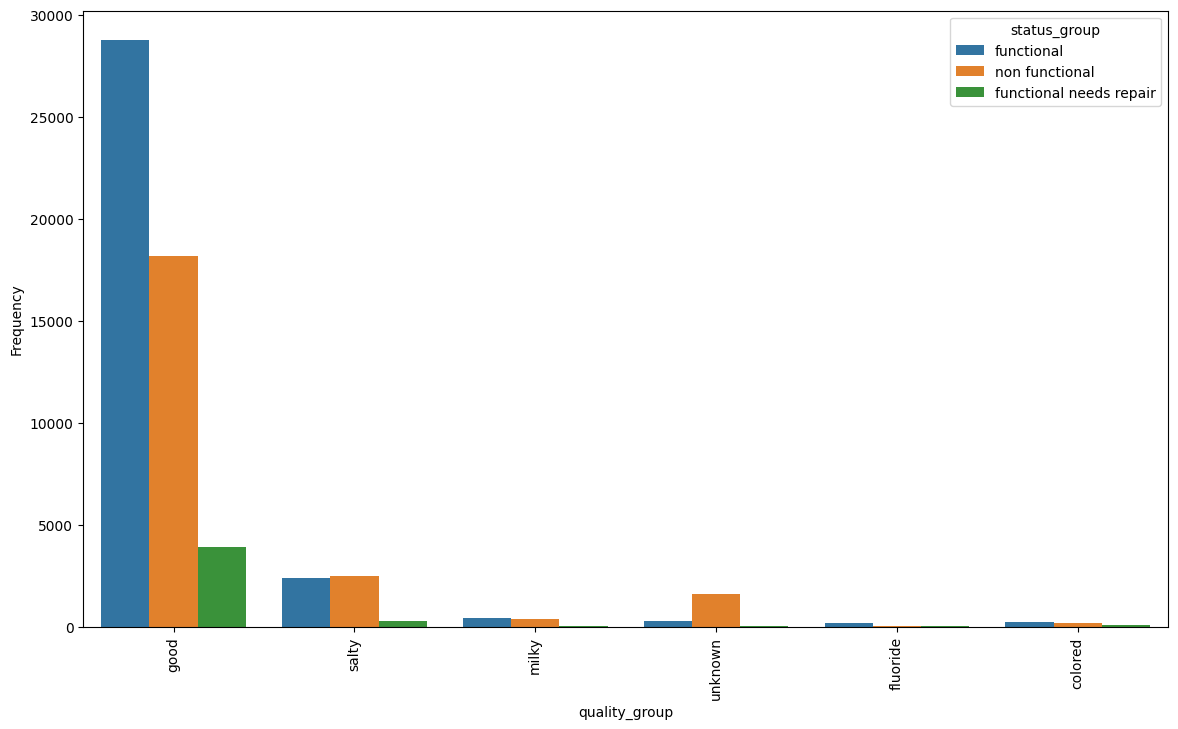

In [23]:
## Count of categories within Scheme_management attribute
sns.countplot(x='quality_group', data=df, hue='status_group')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.show()

### 3. Preprocessing

In [24]:
df[str_features].isna().sum()[df[str_features].isna().sum()>0].sort_values(ascending=False).index

Index(['scheme_name', 'scheme_management', 'installer', 'funder',
       'public_meeting', 'permit', 'subvillage', 'wpt_name'],
      dtype='object')

In [25]:
df_filtered = df.drop(columns=['id','management_group','num_private', 'wpt_name', 
                     'recorded_by', 'subvillage', 'scheme_name', 'region', 
                     'quantity', 'quality_group', 'lga','ward', 'source_type', 'source_class', 'payment', 
                     'waterpoint_type_group','extraction_type_group','extraction_type_class',
                     'status_group'
                    ],axis=1)

In [26]:
df_filtered.columns

Index(['amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer',
       'longitude', 'latitude', 'basin', 'region_code', 'district_code',
       'population', 'public_meeting', 'scheme_management', 'permit',
       'construction_year', 'extraction_type', 'management', 'payment_type',
       'water_quality', 'quantity_group', 'source', 'waterpoint_type',
       'label'],
      dtype='object')

In [27]:
df_filtered.isna().sum()[df_filtered.isna().sum() > 0]

funder               3637
installer            3655
public_meeting       3334
scheme_management    3878
permit               3056
dtype: int64

In [28]:
df_filtered[['funder','scheme_management','installer']] = df_filtered[['funder','scheme_management','installer']].fillna('unknown')
df_filtered['public_meeting'] = df_filtered['public_meeting'].fillna(df_filtered['public_meeting'].mode()[0])
df_filtered['permit'] = df_filtered['permit'].fillna(df_filtered['permit'].mode()[0])


C:\Users\ROG\AppData\Local\Temp\ipykernel_21792\835272975.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filtered['public_meeting'] = df_filtered['public_meeting'].fillna(df_filtered['public_meeting'].mode()[0])
C:\Users\ROG\AppData\Local\Temp\ipykernel_21792\835272975.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filtered['permit'] = df_filtered['permit'].fillna(df_filtered['permit'].mode()[0])


In [29]:
# Get number of unique entries in each column with categorical data
cat_vars = df_filtered.select_dtypes(include='object').columns
object_nunique = list(map(lambda col: df_filtered[col].nunique(), cat_vars))
d = dict(zip(cat_vars, object_nunique))

# Print number of unique entries by column, in ascending order
sorted(d.items(), key=lambda x: x[1])

[('quantity_group', 5),
 ('payment_type', 7),
 ('waterpoint_type', 7),
 ('water_quality', 8),
 ('basin', 9),
 ('source', 10),
 ('scheme_management', 12),
 ('management', 12),
 ('extraction_type', 18),
 ('date_recorded', 356),
 ('funder', 1897),
 ('installer', 2145)]

In [30]:
# Convert all column names to strings
df_filtered.columns = df_filtered.columns.astype(str).str.replace(" ", "_")

In [31]:
# Precompute the top 10 
top10_funders = df_filtered[df_filtered['funder'] != 'unknown']['funder'].value_counts().head(10).index
top10_installer = df_filtered[df_filtered['installer'] != 'unknown']['installer'].value_counts().head(10).index

# Reducte cardinality 
df_filtered['funder_wrangler'] = df_filtered['funder'].where(df_filtered['funder'].isin(top10_funders), 'other')
df_filtered['installer_wrangler'] = df_filtered['installer'].where(df_filtered['installer'].isin(top10_installer), 'other')

Text(0, 0.5, 'Frequency')

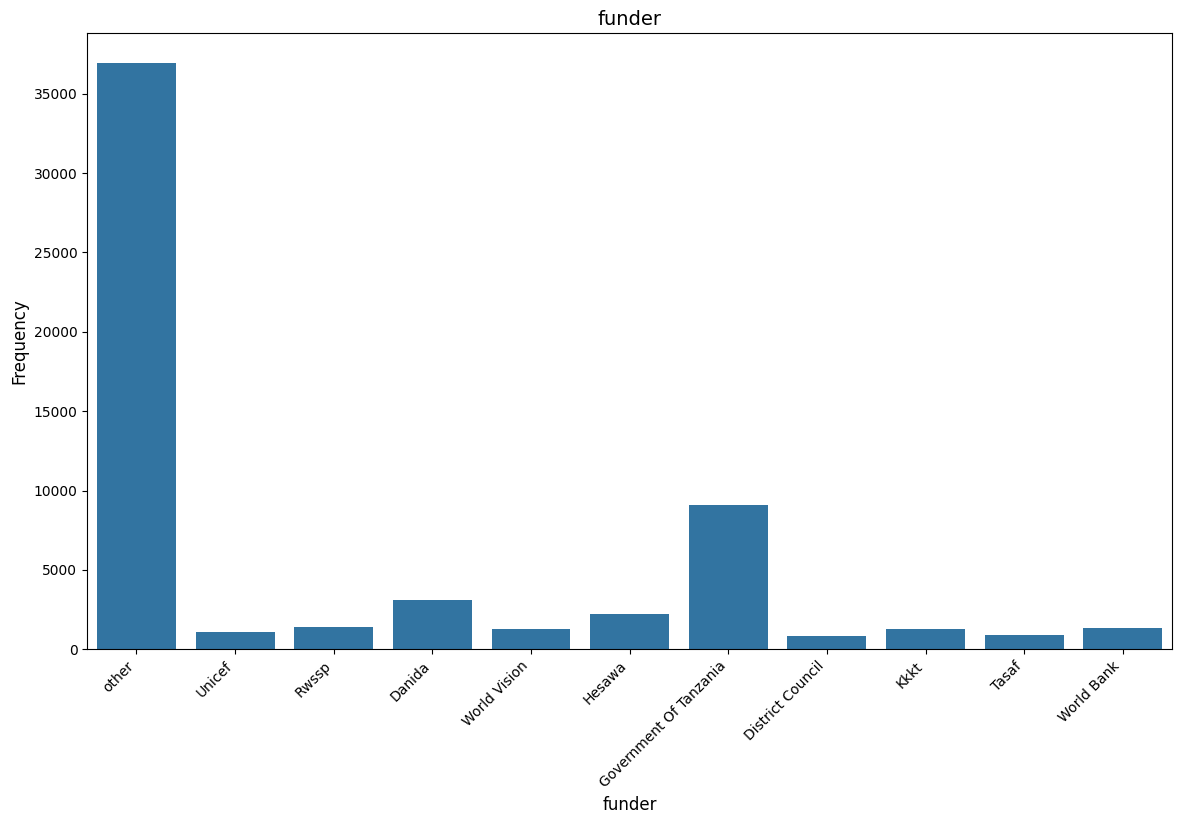

In [32]:
sns.countplot(x=df_filtered["funder_wrangler"])
plt.xticks(rotation=45, 
    horizontalalignment='right')
plt.title("funder", fontsize=14)
plt.xlabel("funder", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

Text(0, 0.5, 'Frequency')

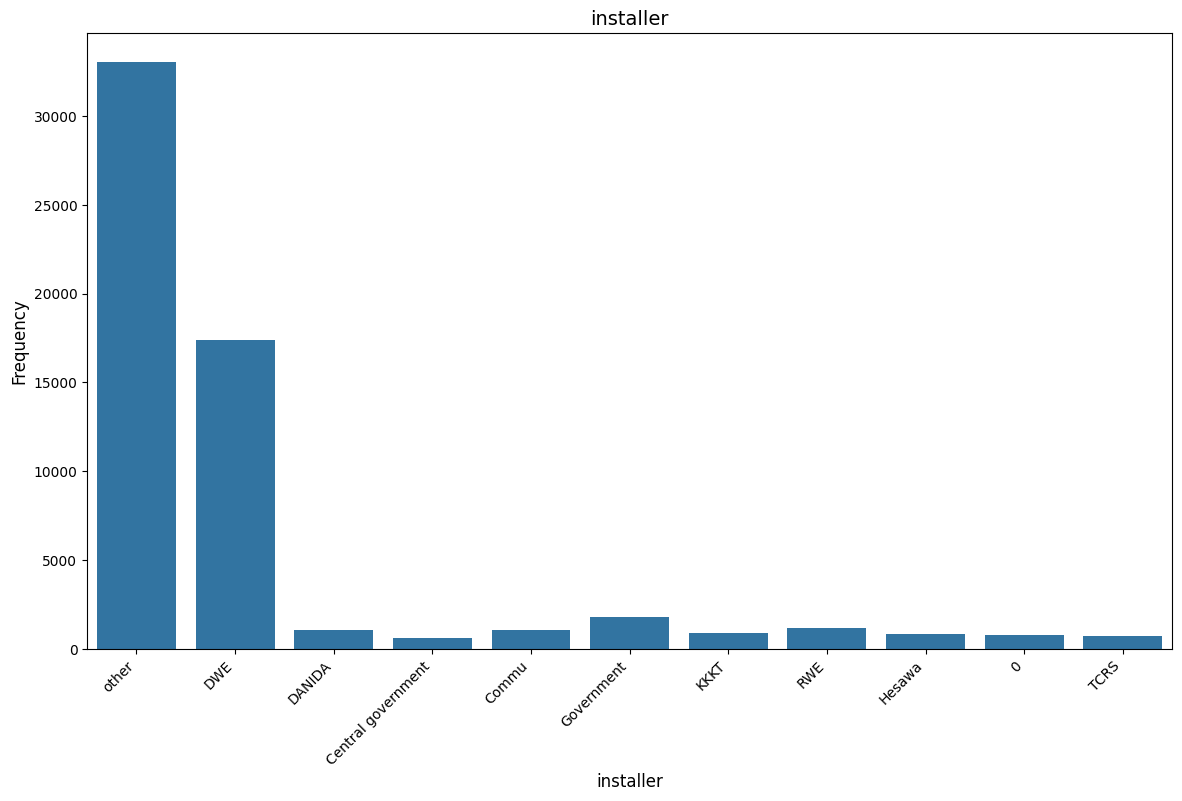

In [33]:
sns.countplot(x=df_filtered["installer_wrangler"])
plt.xticks(rotation=45, 
    horizontalalignment='right')
plt.title("installer", fontsize=14)
plt.xlabel("installer", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

In [34]:
def amount_tsh_more_than_15000(row):  
    if row['amount_tsh'] > 15000:
        return 1
    else:
        return 0
df_filtered['amount_tsh_more_than_15000'] = df_filtered.apply(lambda row: amount_tsh_more_than_15000(row), axis=1)

In [35]:
def construction_wrangler(row):
    if row['construction_year'] >= 1960 and row['construction_year'] < 1970:
        return '60s'
    elif row['construction_year'] >= 1970 and row['construction_year'] < 1980:
        return '70s'
    elif row['construction_year'] >= 1980 and row['construction_year'] < 1990:
        return '80s'
    elif row['construction_year'] >= 1990 and row['construction_year'] < 2000:
        return '90s'
    elif row['construction_year'] >= 2000 and row['construction_year'] < 2010:
        return '00s'
    elif row['construction_year'] >= 2010 and row['construction_year'] < 2020:
        return '10s'
    else:
        return 'unknown'
df_filtered['construction_year_cat'] = df_filtered.apply(lambda row: construction_wrangler(row), axis=1)

Text(0, 0.5, 'No. label')

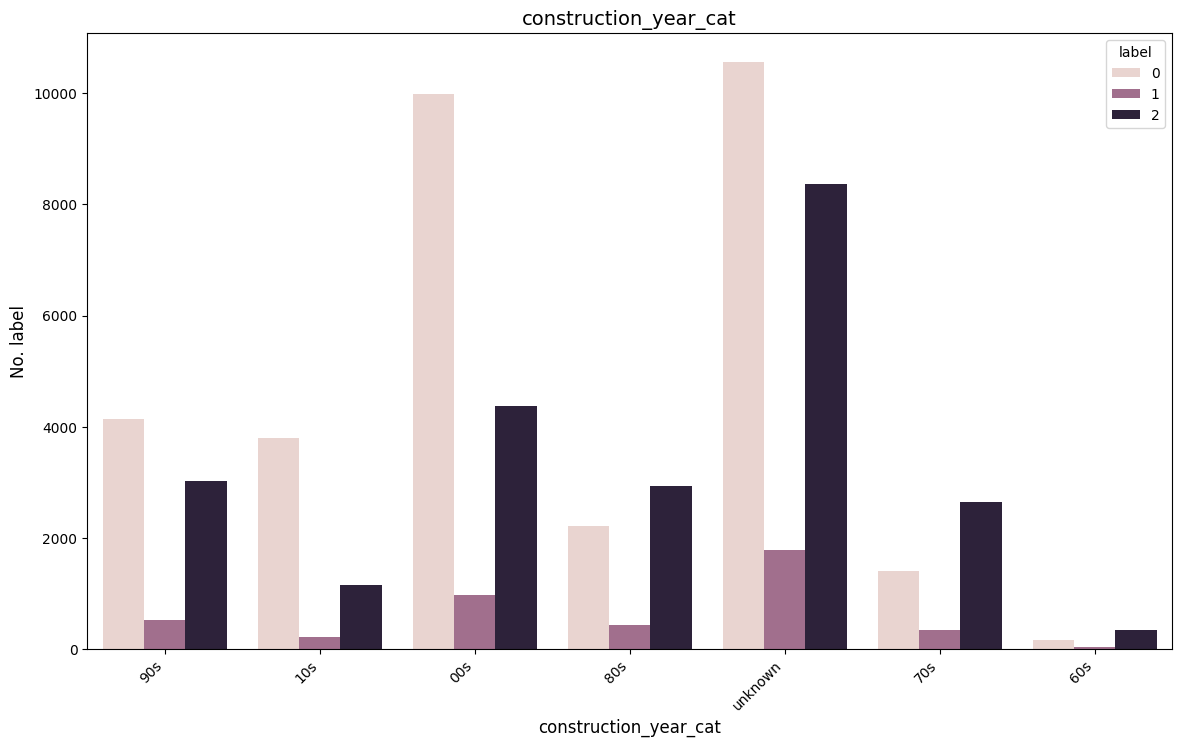

In [36]:
sns.countplot(x=df_filtered["construction_year_cat"],hue=df_filtered["label"])
plt.xticks(rotation=45, 
    horizontalalignment='right')
plt.title("construction_year_cat", fontsize=14)
plt.xlabel("construction_year_cat", fontsize=12)
plt.ylabel("No. label", fontsize=12)

In [37]:
df_filtered[['construction_year','construction_year_cat']].head()

,construction_year,construction_year_cat
0,1999,90s
1,2010,10s
2,2009,00s
3,1986,80s
4,0,unknown


In [38]:
df_filtered.date_recorded = pd.to_datetime(df_filtered.date_recorded)

df_filtered['date_recorded_diff'] = (pd.to_datetime('today') - pd.to_datetime(df_filtered.date_recorded)).dt.days

In [39]:
df_filtered["date_recorded_diff"].nunique()

356

<Axes: xlabel='label', ylabel='date_recorded_diff'>

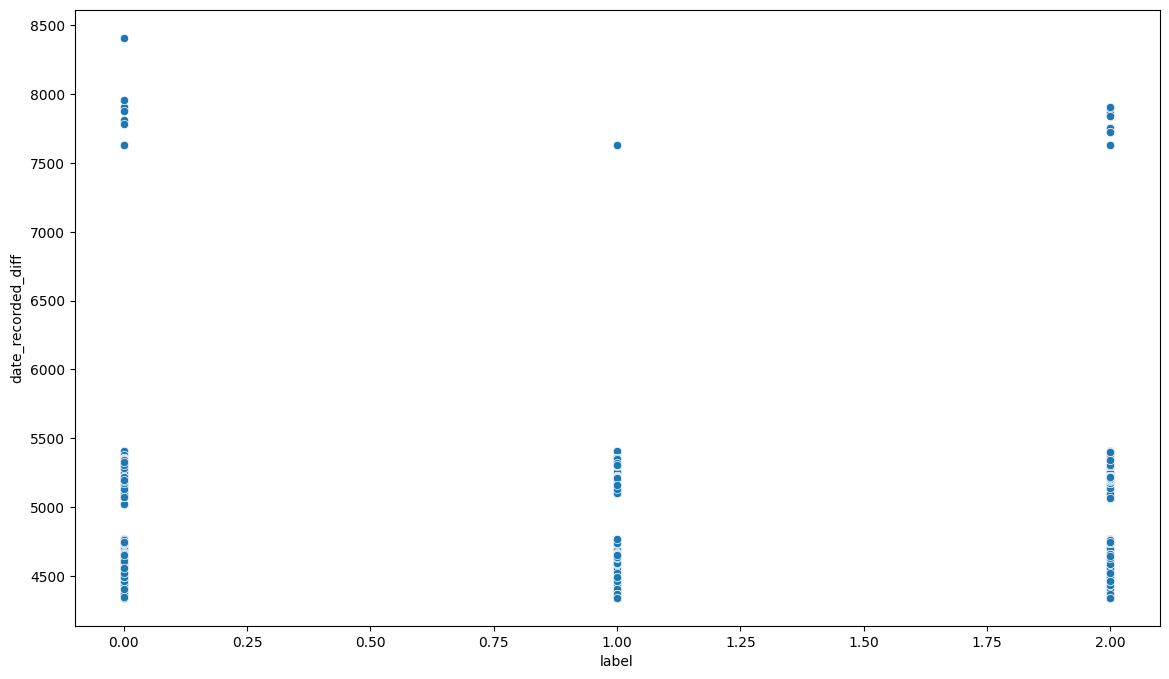

In [42]:
# label_dict = {"functional":0,"functional needs repair":1,"non functional":2}
sns.scatterplot(y=df_filtered["date_recorded_diff"],x=df_filtered["label"])

In [44]:
df_filtered[df_filtered['date_recorded_diff'] > 7000 ].groupby('label')['label'].count()

label
0    11
1     1
2    19
Name: label, dtype: int64

In [39]:
df_filtered['date_recorded_diff']

0        5336
1        4613
2        4622
3        4650
4        5215
         ... 
59395    4555
59396    5282
59397    5308
59398    5342
59399    5327
Name: date_recorded_diff, Length: 59400, dtype: int64

In [40]:
X = df_filtered.drop(["funder","installer","date_recorded",'label'],axis=1)
y = df_filtered['label']
print("The fraction of functional labels in the target :",round((y[y == 0]).shape[0] / y.shape[0],3))
print("The fraction of non functional labels in the target :",round((y[y == 1]).shape[0] / y.shape[0],3))
print("The fraction of functional needs repair labels in the target :",round((y[y == 2]).shape[0] / y.shape[0],3))

The fraction of functional labels in the target : 0.543
The fraction of non functional labels in the target : 0.073
The fraction of functional needs repair labels in the target : 0.384


In [41]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(X.select_dtypes(include='object'))

# Create dataframe with encoded columns
str_columns = X.select_dtypes(include='object').columns
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(str_columns))

# Combine with numerical columns
X = pd.concat([X.select_dtypes(exclude='object').reset_index(drop=True), encoded_df], axis=1)


In [42]:
encoded_df.head()

,basin_Internal,basin_Lake Nyasa,basin_Lake Rukwa,basin_Lake Tanganyika,basin_Lake Victoria,basin_Pangani,basin_Rufiji,basin_Ruvuma / Southern Coast,basin_Wami / Ruvu,scheme_management_Company,...,installer_wrangler_RWE,installer_wrangler_TCRS,installer_wrangler_other,construction_year_cat_00s,construction_year_cat_10s,construction_year_cat_60s,construction_year_cat_70s,construction_year_cat_80s,construction_year_cat_90s,construction_year_cat_unknown
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.4,random_state=314,shuffle=True,stratify=y)
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)
print("Functional labels labels in test targets :",y_test[y_test==0].shape[0])
print("Non functional labels labels in test targets :",y_test[y_test==1].shape[0])
print("Functional needs repair labels labels in test targets :",y_test[y_test==2].shape[0])

Functional labels labels in test targets : 12904
Non functional labels labels in test targets : 1727
Functional needs repair labels labels in test targets : 9129


In [44]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

numerical_features = X.select_dtypes(include=['int64','float64']).columns

X_train[numerical_features] = sc.fit_transform(X_train[numerical_features])
X_test[numerical_features] = sc.transform(X_test[numerical_features])

In [45]:
len(X_train.columns)

129

### 4. Training models

- Logistic Regression with l2 regularization (Ridge regression)

In [46]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(penalty='l2',max_iter=5000).fit(X_train,y_train)
y_pred_log = log_reg.predict(X_test)
print("Accuracy (Logistic Regression) :",round(accuracy_score(y_test,y_pred_log),3))

Accuracy (Logistic Regression) : 0.74


- k-NN

In [47]:
from sklearn.neighbors import KNeighborsClassifier
knn_cls = KNeighborsClassifier(n_neighbors=3).fit(X_train,y_train)
y_pred_knn = knn_cls.predict(X_test)
print("Accuracy (KNN) :",round(accuracy_score(y_test,y_pred_knn),3))

Accuracy (KNN) : 0.762


- Decision Tree

In [48]:
from sklearn.tree import DecisionTreeClassifier
dtree_cls = DecisionTreeClassifier().fit(X_train,y_train)
y_pred_dtree = dtree_cls.predict(X_test)
print("Accuracy (Decision Tree) :",round(accuracy_score(y_test,y_pred_dtree),3))

Accuracy (Decision Tree) : 0.751


- Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier
random_forest_cls = RandomForestClassifier(n_estimators=5).fit(X_train,y_train)
y_pred_rf = random_forest_cls.predict(X_test)
print("Accuracy (Random Forest Classifier) :",round(accuracy_score(y_test,y_pred_rf),3))

Accuracy (Random Forest Classifier) : 0.777


- XGBoost

In [50]:
from xgboost import XGBClassifier

xgb_cls = XGBClassifier(objective='multi:softmax', num_class=3).fit(X_train,y_train)
print("Accuracy (XGBoost) :",round(accuracy_score(y_test,xgb_cls.predict(X_test)),3))

Accuracy (XGBoost) : 0.795


### 5. Parameter Tuning

In [51]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report
target_names = ["functional","functional needs repair","non functional"]
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=314)

In [52]:
log_param_grid = {
    'C': np.logspace(1e-5,1e2, endpoint=True, num=10)
}

log_grid = RandomizedSearchCV(LogisticRegression(max_iter=5000,penalty='l2'),
                            param_distributions=log_param_grid,
                            cv=cv,
                            scoring='accuracy'
                        )
log_grid.fit(X_train, y_train)
print(classification_report(y_test, log_grid.predict(X_test), target_names=target_names))

                         precision    recall  f1-score   support

             functional       0.72      0.90      0.80     12904
functional needs repair       0.51      0.07      0.12      1727
         non functional       0.78      0.65      0.71      9129

               accuracy                           0.74     23760
              macro avg       0.67      0.54      0.54     23760
           weighted avg       0.73      0.74      0.72     23760



In [53]:
log_grid.best_params_

{'C': np.float64(129157609997.87921)}

In [54]:
kNN_param_grid = {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan'],
            'p':[1, 2, 3]
            }

kNN_grid = RandomizedSearchCV(KNeighborsClassifier(),
                            param_distributions=kNN_param_grid,
                            cv=cv,
                            scoring='accuracy'
                        )
kNN_grid.fit(X_train, y_train)
print(classification_report(y_test, kNN_grid.predict(X_test), target_names=target_names))

                         precision    recall  f1-score   support

             functional       0.77      0.87      0.82     12904
functional needs repair       0.49      0.30      0.37      1727
         non functional       0.80      0.71      0.75      9129

               accuracy                           0.77     23760
              macro avg       0.68      0.63      0.65     23760
           weighted avg       0.76      0.77      0.76     23760



In [55]:
kNN_grid.best_params_

{'weights': 'uniform', 'p': 2, 'n_neighbors': 5, 'metric': 'manhattan'}

In [56]:
dtree_param_grid = {
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }

dtree_cls = RandomizedSearchCV(DecisionTreeClassifier(),
                            param_distributions=dtree_param_grid,
                            cv=cv,
                            scoring='accuracy'
                        )
dtree_cls.fit(X_train, y_train)
print(classification_report(y_test, dtree_cls.predict(X_test), target_names=target_names))

                         precision    recall  f1-score   support

             functional       0.78      0.85      0.81     12904
functional needs repair       0.42      0.31      0.36      1727
         non functional       0.79      0.72      0.76      9129

               accuracy                           0.76     23760
              macro avg       0.66      0.63      0.64     23760
           weighted avg       0.76      0.76      0.76     23760



In [57]:
dtree_cls.best_params_

{'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_depth': 20,
 'criterion': 'entropy'}

In [58]:
rf_param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False]
        }

random_forest_cls = RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=rf_param_grid,
                            cv=cv,
                            scoring='accuracy'
                        )
random_forest_cls.fit(X_train, y_train)
print(classification_report(y_test, random_forest_cls.predict(X_test), target_names=target_names))

                         precision    recall  f1-score   support

             functional       0.79      0.92      0.85     12904
functional needs repair       0.61      0.28      0.38      1727
         non functional       0.86      0.75      0.80      9129

               accuracy                           0.81     23760
              macro avg       0.75      0.65      0.68     23760
           weighted avg       0.80      0.81      0.79     23760



In [59]:
random_forest_cls.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': 20,
 'bootstrap': False}

In [60]:
xgboost_param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }

xgb_cls = RandomizedSearchCV(XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss'),
                            param_distributions=xgboost_param_grid,
                            cv=cv,
                            scoring='accuracy'
                        )
xgb_cls.fit(X_train, y_train)
print(classification_report(y_test, xgb_cls.predict(X_test), target_names=target_names))

                         precision    recall  f1-score   support

             functional       0.76      0.92      0.83     12904
functional needs repair       0.66      0.22      0.33      1727
         non functional       0.84      0.70      0.76      9129

               accuracy                           0.78     23760
              macro avg       0.76      0.61      0.64     23760
           weighted avg       0.78      0.78      0.77     23760



In [61]:
xgb_cls.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'max_depth': 5,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [62]:
# Get the best model from RandomizedSearchCV
best_xgb = xgb_cls.best_estimator_

# Get feature importances
importances = best_xgb.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance_df.head(10))

                                         Feature  Importance
78                            quantity_group_dry    0.132166
99                         waterpoint_type_other    0.076790
42                         extraction_type_other    0.046951
13                              basin_Lake Nyasa    0.023729
95   waterpoint_type_communal standpipe multiple    0.023522
125                    construction_year_cat_70s    0.020235
79                         quantity_group_enough    0.019533
102       funder_wrangler_Government Of Tanzania    0.017049
36                       extraction_type_gravity    0.016335
51                            management_company    0.015125


In [65]:
df_test_set = pd.read_csv('test_set_values.csv')

X_test_set = df_test_set.drop(columns=['id','management_group','num_private', 'wpt_name', 
                     'recorded_by', 'subvillage', 'scheme_name', 'region', 
                     'quantity', 'quality_group', 'lga','ward', 'source_type', 'source_class', 'payment', 
                     'waterpoint_type_group','extraction_type_group','extraction_type_class'
                    ],axis=1)

X_test_set[['funder','scheme_management','installer']] = X_test_set[['funder','scheme_management','installer']].fillna('unknown')
X_test_set['public_meeting'] = X_test_set['public_meeting'].fillna(df_filtered['public_meeting'].mode()[0])
X_test_set['permit'] = X_test_set['permit'].fillna(df_filtered['permit'].mode()[0])

X_test_set.columns = X_test_set.columns.astype(str).str.replace(" ", "_")

X_test_set['funder_wrangler'] = X_test_set['funder'].where(X_test_set['funder'].isin(top10_funders), 'other')
X_test_set['installer_wrangler'] = X_test_set['installer'].where(X_test_set['installer'].isin(top10_installer), 'other')

X_test_set['amount_tsh_more_than_15000'] = X_test_set.apply(lambda row: amount_tsh_more_than_15000(row), axis=1)

X_test_set['construction_year_cat'] = X_test_set.apply(lambda row: construction_wrangler(row), axis=1)

X_test_set.date_recorded = pd.to_datetime(X_test_set.date_recorded)
X_test_set['date_recorded_diff'] = (pd.to_datetime('today') - pd.to_datetime(X_test_set.date_recorded)).dt.days

X_test_set = X_test_set.drop(["funder","installer","date_recorded"],axis=1)

encoded = encoder.transform(X_test_set.select_dtypes(include='object'))
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(str_columns))
X_test_set = pd.concat([X_test_set.select_dtypes(exclude='object').reset_index(drop=True), encoded_df], axis=1)

X_test_set[numerical_features] = sc.transform(X_test_set[numerical_features])

prediction = random_forest_cls.predict(X_test_set)

# Create reverse mapping (value → key)
reverse_label_dict = {v: k for k, v in label_dict.items()}

# Map numeric labels back to text
y_pred_labels = np.vectorize(reverse_label_dict.get)(prediction)

df_test_set['status_group'] = y_pred_labels
df_test_set[['id','status_group']].to_csv('prediction.csv',index=False)

C:\Users\ROG\AppData\Local\Temp\ipykernel_8188\1095268188.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_set['public_meeting'] = X_test_set['public_meeting'].fillna(df_filtered['public_meeting'].mode()[0])
C:\Users\ROG\AppData\Local\Temp\ipykernel_8188\1095268188.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_set['permit'] = X_test_set['permit'].fillna(df_filtered['permit'].mode()[0])
